# **WHEEL DIAMETER**

In [ ]:
import pandas as pd
df = pd.read_csv("/content/wheelmtbf.csv")
df

,Date,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
0,2018-06-22,T01,M1,BOG#1,X1-LHS,843.22,29.02,0,2018Q2,0,91,0.000000
1,2018-06-22,T01,M1,BOG#1,X1-RHS,843.93,29.26,0,2018Q2,0,91,0.000000
2,2018-06-22,T01,M1,BOG#1,X2-LHS,844.14,29.80,0,2018Q2,0,91,0.000000
3,2018-06-22,T01,M1,BOG#1,X2-RHS,844.76,29.53,0,2018Q2,0,91,0.000000
4,2018-06-22,T01,M1,BOG#2,X3-LHS,844.86,29.80,0,2018Q2,0,91,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4918,2025-03-13,T58,M2,BOG#1,X2-RHS,818.00,30.07,0,2025Q1,11,90,147.272727
4919,2025-03-13,T58,M2,BOG#2,X3-LHS,816.30,30.52,0,2025Q1,11,90,147.272727
4920,2025-03-13,T58,M2,BOG#2,X3-RHS,812.10,30.00,0,2025Q1,11,90,147.272727
4921,2025-03-13,T58,M2,BOG#2,X4-LHS,812.10,30.01,0,2025Q1,11,90,147.272727


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

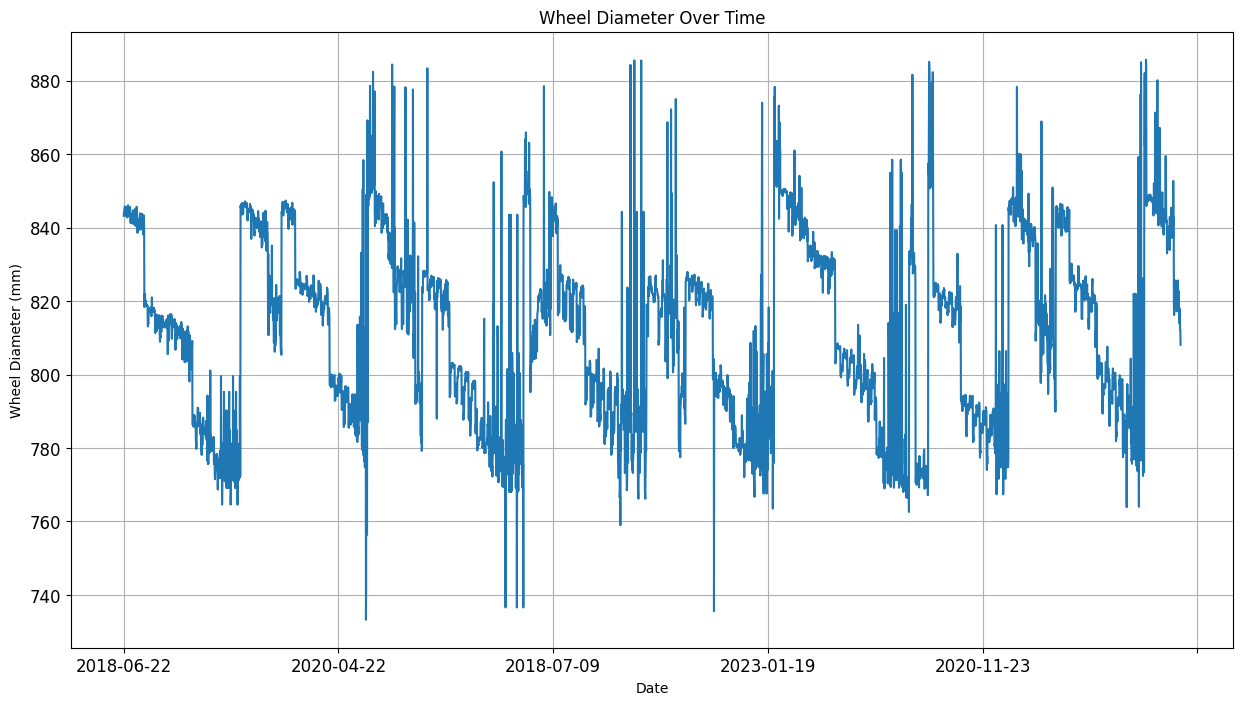

In [ ]:
#plot the time series data
df.set_index('Date', inplace=True)  # Make sure 'Date' is parsed to datetime
df['WheelDiameter'].plot(figsize=(15, 8), title='Wheel Diameter Over Time', fontsize=12)
plt.ylabel('Wheel Diameter (mm)')
plt.grid(True)

In [ ]:
training_wd = df[0:4429] # in-sample data (training data)
testing_wd = df[4429:] #out-sample data (testing data)

In [ ]:
training_wd

,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
Date,,,,,,,,,,,
2018-06-22,T01,M1,BOG#1,X1-LHS,843.22,29.02,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X1-RHS,843.93,29.26,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-LHS,844.14,29.80,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-RHS,844.76,29.53,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#2,X3-LHS,844.86,29.80,0,2018Q2,0,91,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-11-12,T58,T2,BOG#1,X2-RHS,825.91,32.67,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-LHS,826.94,32.16,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-RHS,826.61,32.10,0,2018Q4,2,92,828.0


In [ ]:
testing_wd

,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
Date,,,,,,,,,,,
2018-11-12,T58,M2,BOG#1,X1-LHS,824.86,32.30,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#1,X1-RHS,824.94,32.18,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#1,X2-LHS,817.10,31.94,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#1,X2-RHS,817.09,32.24,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#2,X3-LHS,817.47,32.18,0,2018Q4,2,92,828.000000
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-13,T58,M2,BOG#1,X2-RHS,818.00,30.07,0,2025Q1,11,90,147.272727
2025-03-13,T58,M2,BOG#2,X3-LHS,816.30,30.52,0,2025Q1,11,90,147.272727
2025-03-13,T58,M2,BOG#2,X3-RHS,812.10,30.00,0,2025Q1,11,90,147.272727


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

# Fit triple exponential smoothing model
model1 = ExponentialSmoothing(training_wd['WheelDiameter'], trend='add', seasonal='add', seasonal_periods=4).fit()
model1.summary()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Dep. Variable:,WheelDiameter,No. Observations:,4429
Model:,ExponentialSmoothing,SSE,473990.730
Optimized:,True,AIC,20712.779
Trend:,Additive,BIC,20763.946
Seasonal:,Additive,AICC,20712.829
Seasonal Periods:,4,Date:,"Sun, 08 Jun 2025"
Box-Cox:,False,Time:,14:32:15
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.3995288,alpha,True
smoothing_trend,0.0002399,beta,True


In [ ]:
# initialize variables for storing predictions and actual values
predictions1 = []
actuals = []

# iterate over each time step in the testing data
for i in range(len(testing_wd)):
    # make one-step ahead forecast
    yhat = model1.forecast()

    # store prediction and actual value
    predictions1.append(yhat)
    actuals.append(testing_wd.iloc[i])

    # add actual value to training data
    training_wd = pd.concat([training_wd, pd.DataFrame([testing_wd.iloc[i]], columns=training_wd.columns)], ignore_index=True)

    # retrain model on updated training data
    model1 = ExponentialSmoothing(training_wd['WheelDiameter'], trend='add', seasonal='add', seasonal_periods=4).fit()
    model1.summary()

    actual_value1 = testing_wd.iloc[-1]

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
predictions1

[4429    824.805097
 dtype: float64,
 4430    825.132048
 dtype: float64,
 4431    824.96226
 dtype: float64,
 4432    821.910039
 dtype: float64,
 4433    819.752346
 dtype: float64,
 4434    819.173665
 dtype: float64,
 4435    818.400341
 dtype: float64,
 4436    820.719457
 dtype: float64,
 4437    821.855815
 dtype: float64,
 4438    822.839436
 dtype: float64,
 4439    822.943074
 dtype: float64,
 4440    823.078388
 dtype: float64,
 4441    822.681284
 dtype: float64,
 4442    823.73893
 dtype: float64,
 4443    823.591715
 dtype: float64,
 4444    823.592022
 dtype: float64,
 4445    823.217465
 dtype: float64,
 4446    825.759288
 dtype: float64,
 4447    827.123855
 dtype: float64,
 4448    827.867405
 dtype: float64,
 4449    828.06685
 dtype: float64,
 4450    827.040243
 dtype: float64,
 4451    825.906344
 dtype: float64,
 4452    825.451813
 dtype: float64,
 4453    824.579329
 dtype: float64,
 4454    824.886422
 dtype: float64,
 4455    824.452913
 dtype: float64,
 445

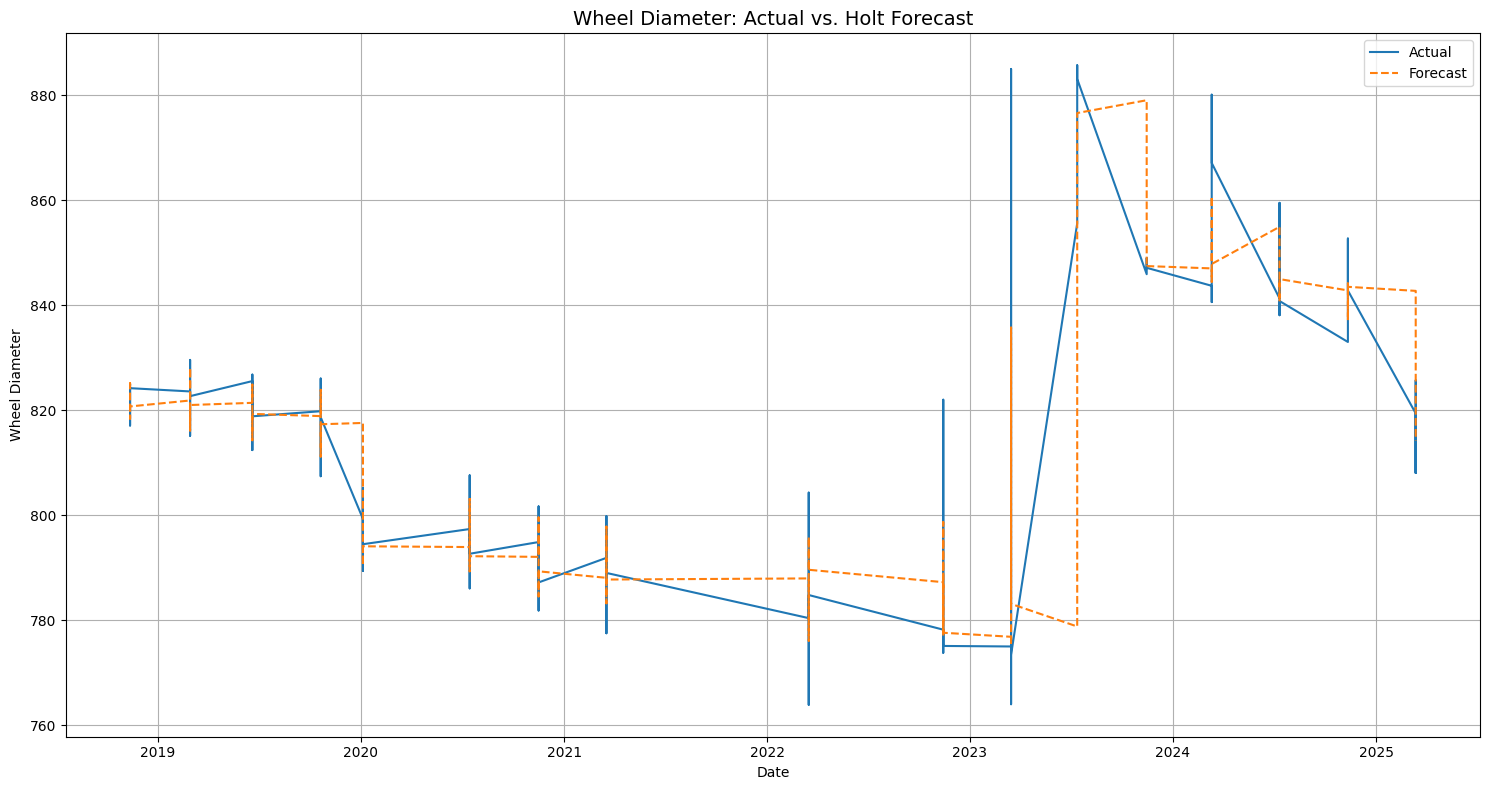

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure testing index is datetime
if not np.issubdtype(testing_wd.index.dtype, np.datetime64):
    testing_wd.index = pd.to_datetime(testing_wd.index)

# Convert predictions into array and ensure shape matches testing set
a = np.array(predictions1)

# Create DataFrame for forecast with the same index as testing
testing_forecasted1 = pd.DataFrame(a, columns=['forecast1'], index=testing_wd.index)

# Combine actual and predicted values
result = pd.DataFrame({
    'Actual WheelDiameter': testing_wd['WheelDiameter'],
    'Predicted WheelDiameter': testing_forecasted1['forecast1']
})

# Plotting
plt.figure(figsize=(15, 8))
plt.plot(result['Actual WheelDiameter'], label='Actual')
plt.plot(result['Predicted WheelDiameter'], label='Forecast', linestyle='--')
plt.title('Wheel Diameter: Actual vs. Holt Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Wheel Diameter')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Display the top rows of the result DataFrame
print(result.head(10))

            Actual WheelDiameter  Predicted WheelDiameter
Date                                                     
2018-11-12                824.86               824.805097
2018-11-12                824.94               825.132048
2018-11-12                817.10               824.962260
2018-11-12                817.09               821.910039
2018-11-12                817.47               819.752346
2018-11-12                817.51               819.173665
2018-11-12                824.14               818.400341
2018-11-12                824.20               820.719457
2019-02-28                823.58               821.855815
2019-02-28                823.36               822.839436


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Actual and predicted values
y_true = testing_wd['WheelDiameter'].values
y_pred = testing_forecasted1['forecast1'].values

# Evaluation metrics
r2 = r2_score(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # in percentage

# Print results
print(f"R² Score      : {r2:.4f}")
print(f"MSE           : {mse:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"MAE           : {mae:.4f}")
print(f"MAPE (%)      : {mape:.2f}%")


R² Score      : 0.7821
MSE           : 142.0904
RMSE          : 11.9202
MAE           : 5.6323
MAPE (%)      : 0.69%


In [ ]:
import pandas as pd

# Parameters
future_start_date = '2026-01-01'
n_periods = 4
freq = 'Q'
TrainID = ['T01', 'T05', 'T25', 'T45', 'T46', 'T55', 'T57', 'T58']

# Generate future dates
future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)

# Forecast 4 quarters ahead using the model
forecast_values1 = model1.forecast(steps=n_periods)

# Create forecast DataFrame
forecasts1 = pd.DataFrame()

# Assign same forecast to each TrainID
for train_id in TrainID:
    temp_df = pd.DataFrame({
        'TrainID': [train_id] * n_periods,
        'Date': future_dates,
        'Forecast': forecast_values1
    })
    forecasts1 = pd.concat([forecasts1, temp_df], ignore_index=True)

# Display result
print(forecasts1)


   TrainID       Date    Forecast
0      T01 2026-03-31  811.300235
1      T01 2026-06-30  811.634300
2      T01 2026-09-30  811.175852
3      T01 2026-12-31  811.793777
4      T05 2026-03-31  811.300235
5      T05 2026-06-30  811.634300
6      T05 2026-09-30  811.175852
7      T05 2026-12-31  811.793777
8      T25 2026-03-31  811.300235
9      T25 2026-06-30  811.634300
10     T25 2026-09-30  811.175852
11     T25 2026-12-31  811.793777
12     T45 2026-03-31  811.300235
13     T45 2026-06-30  811.634300
14     T45 2026-09-30  811.175852
15     T45 2026-12-31  811.793777
16     T46 2026-03-31  811.300235
17     T46 2026-06-30  811.634300
18     T46 2026-09-30  811.175852
19     T46 2026-12-31  811.793777
20     T55 2026-03-31  811.300235
21     T55 2026-06-30  811.634300
22     T55 2026-09-30  811.175852
23     T55 2026-12-31  811.793777
24     T57 2026-03-31  811.300235
25     T57 2026-06-30  811.634300
26     T57 2026-09-30  811.175852
27     T57 2026-12-31  811.793777
28     T58 202

<ipython-input-14-723853195715>:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)


In [ ]:
import pandas as pd

# Parameters
future_start_date = '2026-01-01'
n_periods = 4
freq = 'Q'
TrainID = ['T01', 'T05', 'T25', 'T45', 'T46', 'T55', 'T57', 'T58']

# Generate future quarterly dates
future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)

# Forecast 4 quarters ahead using the model
forecast_values1 = model1.forecast(steps=n_periods)

# Create forecast DataFrame
forecasts1 = pd.DataFrame()

# Assign same forecast to each TrainID
for train_id in TrainID:
    temp_df = pd.DataFrame({
        'TrainID': [train_id] * n_periods,
        'Date': future_dates,
        'Forecast': forecast_values1
    })
    forecasts1 = pd.concat([forecasts1, temp_df], ignore_index=True)

# Add maintenance flag
forecasts1['NeedsMaintenance'] = forecasts1['Forecast'] < 755

# Show full forecast with flag
print(forecasts1)

# Optional: Filter only those that need maintenance
maintenance_needed = forecasts1[forecasts1['NeedsMaintenance'] == True]
print("\n🔧 Forecasted Maintenance Dates:\n")
print(maintenance_needed)


   TrainID       Date    Forecast  NeedsMaintenance
0      T01 2026-03-31  811.300235             False
1      T01 2026-06-30  811.634300             False
2      T01 2026-09-30  811.175852             False
3      T01 2026-12-31  811.793777             False
4      T05 2026-03-31  811.300235             False
5      T05 2026-06-30  811.634300             False
6      T05 2026-09-30  811.175852             False
7      T05 2026-12-31  811.793777             False
8      T25 2026-03-31  811.300235             False
9      T25 2026-06-30  811.634300             False
10     T25 2026-09-30  811.175852             False
11     T25 2026-12-31  811.793777             False
12     T45 2026-03-31  811.300235             False
13     T45 2026-06-30  811.634300             False
14     T45 2026-09-30  811.175852             False
15     T45 2026-12-31  811.793777             False
16     T46 2026-03-31  811.300235             False
17     T46 2026-06-30  811.634300             False
18     T46 2

<ipython-input-15-af972d5393e1>:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)


# **MTBF**

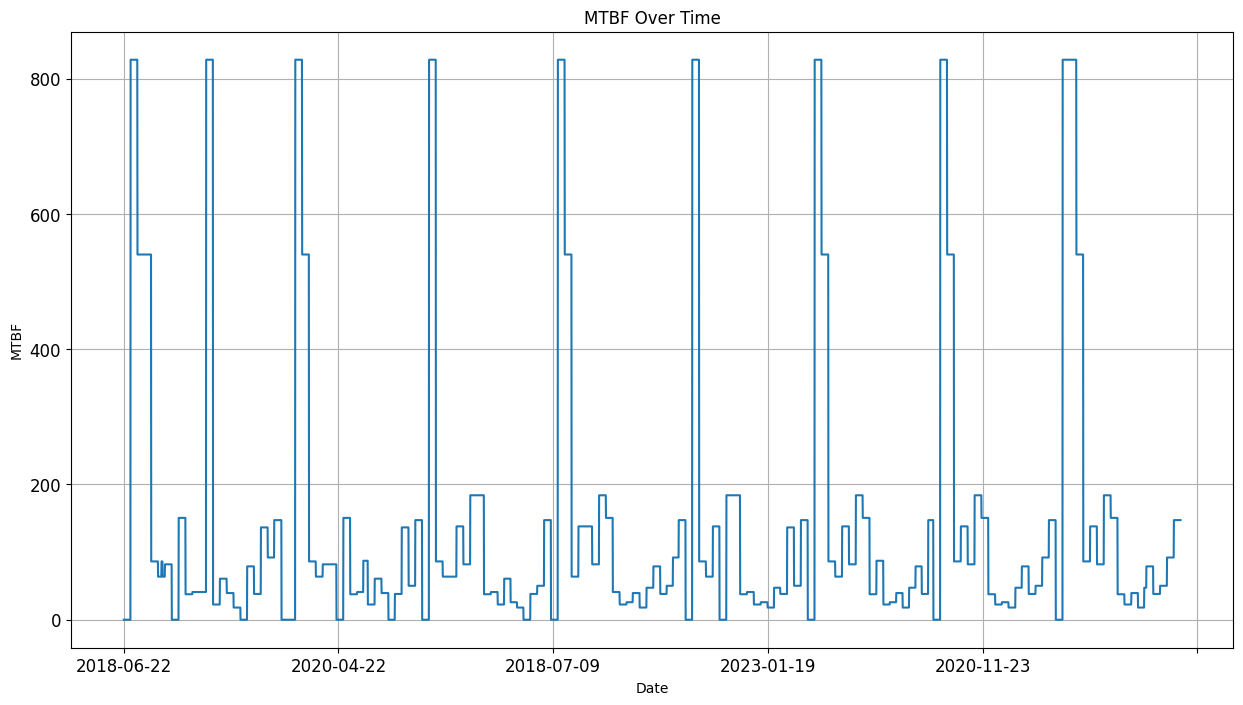

In [ ]:
#plot the time series data
#df.set_index('Date', inplace=True)  # Make sure 'Date' is parsed to datetime
df['MTBF'].plot(figsize=(15, 8), title='MTBF Over Time', fontsize=12)
plt.ylabel('MTBF')
plt.grid(True)

In [ ]:
training_mtbf = df[0:4429] # in-sample data (training data)
testing_mtbf = df[4429:] #out-sample data (testing data)

In [ ]:
training_mtbf

,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
Date,,,,,,,,,,,
2018-06-22,T01,M1,BOG#1,X1-LHS,843.22,29.02,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X1-RHS,843.93,29.26,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-LHS,844.14,29.80,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-RHS,844.76,29.53,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#2,X3-LHS,844.86,29.80,0,2018Q2,0,91,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-11-12,T58,T2,BOG#1,X2-RHS,825.91,32.67,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-LHS,826.94,32.16,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-RHS,826.61,32.10,0,2018Q4,2,92,828.0


In [ ]:
testing_mtbf

,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
Date,,,,,,,,,,,
2018-11-12,T58,M2,BOG#1,X1-LHS,824.86,32.30,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#1,X1-RHS,824.94,32.18,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#1,X2-LHS,817.10,31.94,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#1,X2-RHS,817.09,32.24,0,2018Q4,2,92,828.000000
2018-11-12,T58,M2,BOG#2,X3-LHS,817.47,32.18,0,2018Q4,2,92,828.000000
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-13,T58,M2,BOG#1,X2-RHS,818.00,30.07,0,2025Q1,11,90,147.272727
2025-03-13,T58,M2,BOG#2,X3-LHS,816.30,30.52,0,2025Q1,11,90,147.272727
2025-03-13,T58,M2,BOG#2,X3-RHS,812.10,30.00,0,2025Q1,11,90,147.272727


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

# Fit triple exponential smoothing model
model2 = ExponentialSmoothing(training_wd['MTBF'], trend='add', seasonal='add', seasonal_periods=4).fit()
model2.summary()

Dep. Variable:,MTBF,No. Observations:,4923
Model:,ExponentialSmoothing,SSE,10250944.899
Optimized:,True,AIC,37633.662
Trend:,Additive,BIC,37685.676
Seasonal:,Additive,AICC,37633.707
Seasonal Periods:,4,Date:,"Sun, 08 Jun 2025"
Box-Cox:,False,Time:,14:39:53
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9970271,alpha,True
smoothing_trend,5.9579e-05,beta,True


In [ ]:
# initialize variables for storing predictions and actual values
predictions2 = []
actuals = []

# iterate over each time step in the testing data
for i in range(len(testing_wd)):
    # make one-step ahead forecast
    yhat = model2.forecast()

    # store prediction and actual value
    predictions2.append(yhat)
    actuals.append(testing_mtbf.iloc[i])

    # add actual value to training data
    training_mtbf = pd.concat([training_mtbf, pd.DataFrame([testing_mtbf.iloc[i]], columns=training_mtbf.columns)], ignore_index=True)

    # retrain model on updated training data
    model2 = ExponentialSmoothing(training_mtbf['MTBF'], trend='add', seasonal='add', seasonal_periods=4).fit()
    model2.summary()

    actual_value2 = testing_mtbf.iloc[-1]

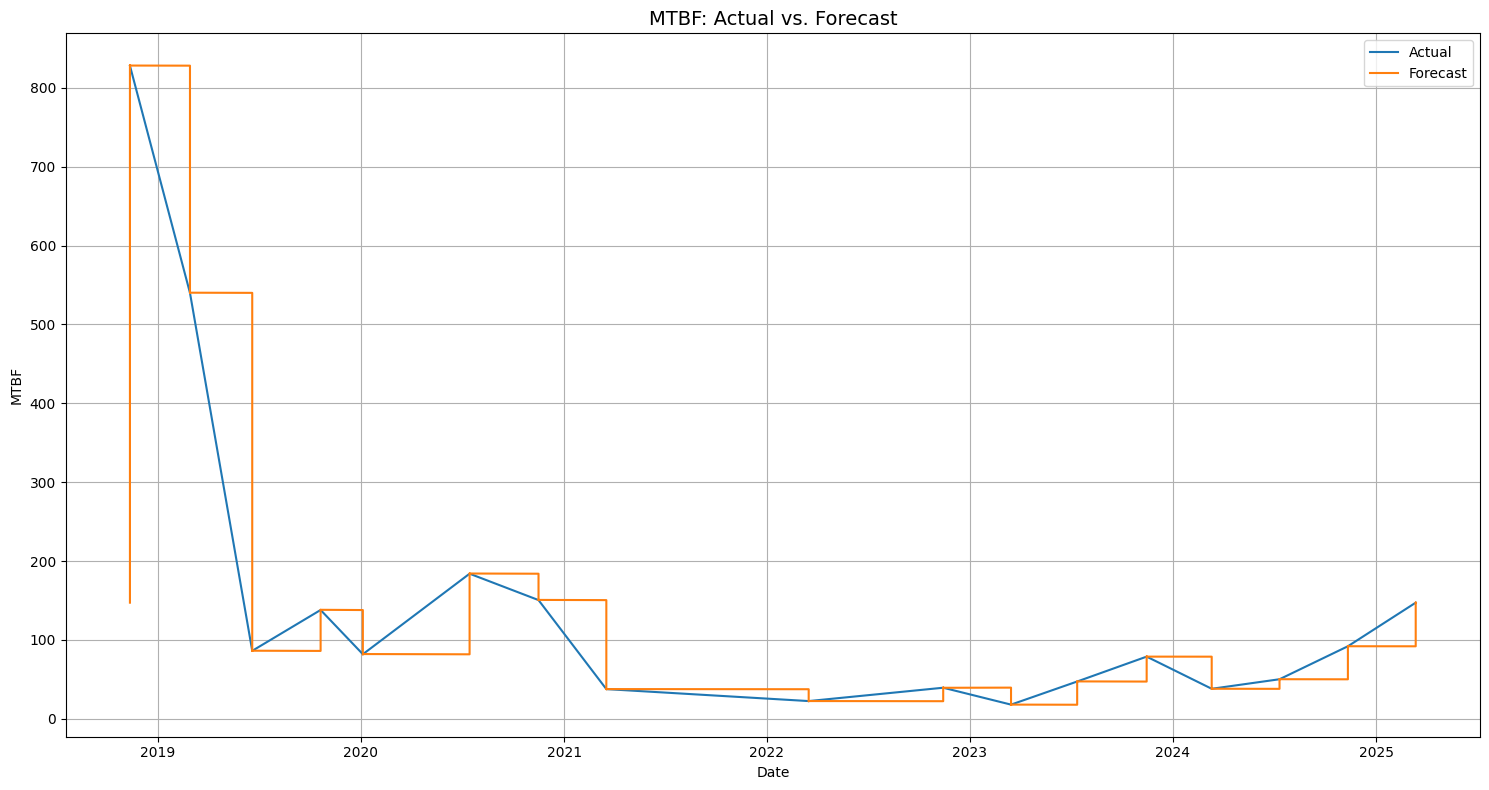

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure testing index is datetime
if not np.issubdtype(testing_mtbf.index.dtype, np.datetime64):
    testing_mtbf.index = pd.to_datetime(testing_mtbf.index)

# Convert predictions into array and ensure shape matches testing set
b = np.array(predictions2)

# Create DataFrame for forecast with the same index as testing
testing_forecasted2 = pd.DataFrame(b, columns=['forecast2'], index=testing_mtbf.index)

# Combine actual and predicted values
result2 = pd.DataFrame({
    'Actual MTBF': testing_mtbf['MTBF'],
    'Predicted MTBF': testing_forecasted2['forecast2']
})

# Plotting
plt.figure(figsize=(15, 8))
# Use result2 which contains the MTBF actual and predicted values
plt.plot(result2['Actual MTBF'], label='Actual')
plt.plot(result2['Predicted MTBF'], label='Forecast')
plt.title('MTBF: Actual vs. Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('MTBF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Display the top rows of the result DataFrame
print(result2.head(10))

            Actual MTBF  Predicted MTBF
Date                                   
2018-11-12        828.0      147.271211
2018-11-12        828.0      828.034475
2018-11-12        828.0      828.064892
2018-11-12        828.0      828.267151
2018-11-12        828.0      828.570042
2018-11-12        828.0      828.036895
2018-11-12        828.0      828.064857
2018-11-12        828.0      828.264289
2019-02-28        540.0      828.118293
2019-02-28        540.0      541.431727


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Actual and predicted values
y_true2 = testing_mtbf['MTBF'].values
y_pred2 = testing_forecasted2['forecast2'].values

# Evaluation metrics
r2 = r2_score(y_true2, y_pred2)
mse = mean_squared_error(y_true2, y_pred2)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true2, y_pred2)
mape = np.mean(np.abs((y_true2 - y_pred2) / y_true2)) * 100  # in percentage

# Print results
print(f"R² Score      : {r2:.4f}")
print(f"MSE           : {mse:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"MAE           : {mae:.4f}")
print(f"MAPE (%)      : {mape:.2f}%")

R² Score      : 0.9308
MSE           : 1603.2297
RMSE          : 40.0404
MAE           : 4.2499
MAPE (%)      : 3.62%


In [ ]:
import pandas as pd

# Parameters
future_start_date = '2026-01-01'
n_periods = 4
freq = 'Q'
TrainID = ['T01', 'T05', 'T25', 'T45', 'T46', 'T55', 'T57', 'T58']

# Generate future dates
future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)

# Forecast 4 quarters ahead using the model
forecast_values2 = model2.forecast(steps=n_periods)

# Create forecast DataFrame
forecasts2 = pd.DataFrame()

# Assign same forecast to each TrainID
for train_id in TrainID:
    temp_df = pd.DataFrame({
        'TrainID': [train_id] * n_periods,
        'Date': future_dates,
        'Forecast': forecast_values2
    })
    forecasts2 = pd.concat([forecasts2, temp_df], ignore_index=True)

# Display result
print(forecasts2)

   TrainID       Date    Forecast
0      T01 2026-03-31  147.271211
1      T01 2026-06-30  147.092559
2      T01 2026-09-30  147.325377
3      T01 2026-12-31  147.698312
4      T05 2026-03-31  147.271211
5      T05 2026-06-30  147.092559
6      T05 2026-09-30  147.325377
7      T05 2026-12-31  147.698312
8      T25 2026-03-31  147.271211
9      T25 2026-06-30  147.092559
10     T25 2026-09-30  147.325377
11     T25 2026-12-31  147.698312
12     T45 2026-03-31  147.271211
13     T45 2026-06-30  147.092559
14     T45 2026-09-30  147.325377
15     T45 2026-12-31  147.698312
16     T46 2026-03-31  147.271211
17     T46 2026-06-30  147.092559
18     T46 2026-09-30  147.325377
19     T46 2026-12-31  147.698312
20     T55 2026-03-31  147.271211
21     T55 2026-06-30  147.092559
22     T55 2026-09-30  147.325377
23     T55 2026-12-31  147.698312
24     T57 2026-03-31  147.271211
25     T57 2026-06-30  147.092559
26     T57 2026-09-30  147.325377
27     T57 2026-12-31  147.698312
28     T58 202

<ipython-input-25-172f393b30d8>:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)


# **WHEEL FLANGE**

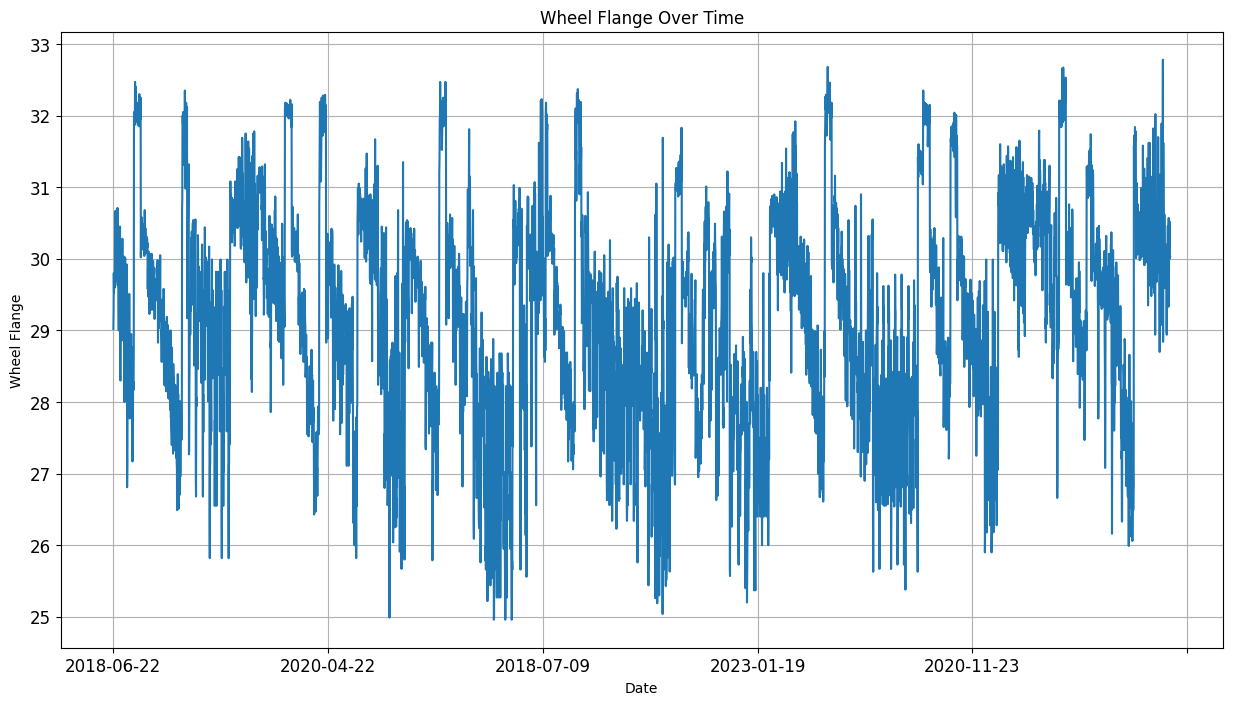

In [ ]:
df['WheelFlange'].plot(figsize=(15, 8), title='Wheel Flange Over Time', fontsize=12)
plt.ylabel('Wheel Flange')
plt.grid(True)

In [ ]:
training_wf = df[0:4429] # in-sample data (training data)
testing_wf = df[4429:] #out-sample data (testing data)

In [ ]:
training_wf

,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
Date,,,,,,,,,,,
2018-06-22,T01,M1,BOG#1,X1-LHS,843.22,29.02,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X1-RHS,843.93,29.26,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-LHS,844.14,29.80,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-RHS,844.76,29.53,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#2,X3-LHS,844.86,29.80,0,2018Q2,0,91,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-11-12,T58,T2,BOG#1,X2-RHS,825.91,32.67,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-LHS,826.94,32.16,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-RHS,826.61,32.10,0,2018Q4,2,92,828.0


In [ ]:
training_wf

,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
Date,,,,,,,,,,,
2018-06-22,T01,M1,BOG#1,X1-LHS,843.22,29.02,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X1-RHS,843.93,29.26,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-LHS,844.14,29.80,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#1,X2-RHS,844.76,29.53,0,2018Q2,0,91,0.0
2018-06-22,T01,M1,BOG#2,X3-LHS,844.86,29.80,0,2018Q2,0,91,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-11-12,T58,T2,BOG#1,X2-RHS,825.91,32.67,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-LHS,826.94,32.16,0,2018Q4,2,92,828.0
2018-11-12,T58,T2,BOG#2,X3-RHS,826.61,32.10,0,2018Q4,2,92,828.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

# Fit triple exponential smoothing model
model3 = ExponentialSmoothing(training_wf['WheelFlange'], trend='add', seasonal='add', seasonal_periods=4).fit()
model3.summary()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Dep. Variable:,WheelFlange,No. Observations:,4429
Model:,ExponentialSmoothing,SSE,2703.732
Optimized:,True,AIC,-2169.892
Trend:,Additive,BIC,-2118.724
Seasonal:,Additive,AICC,-2169.842
Seasonal Periods:,4,Date:,"Sun, 08 Jun 2025"
Box-Cox:,False,Time:,14:47:29
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.5587588,alpha,True
smoothing_trend,8.8262e-19,beta,True


In [ ]:
# initialize variables for storing predictions and actual values
predictions3 = []
actuals = []

# iterate over each time step in the testing data
for i in range(len(testing_wf)):
    # make one-step ahead forecast
    yhat = model3.forecast()

    # store prediction and actual value
    predictions3.append(yhat)
    actuals.append(testing_wf.iloc[i])

    # add actual value to training data
    training_wf = pd.concat([training_wf, pd.DataFrame([testing_wf.iloc[i]], columns=training_wf.columns)], ignore_index=True)

    # retrain model on updated training data
    model3 = ExponentialSmoothing(training_wf['WheelFlange'], trend='add', seasonal='add', seasonal_periods=4).fit()
    model3.summary()

    actual_value3= testing_wf.iloc[-1]

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


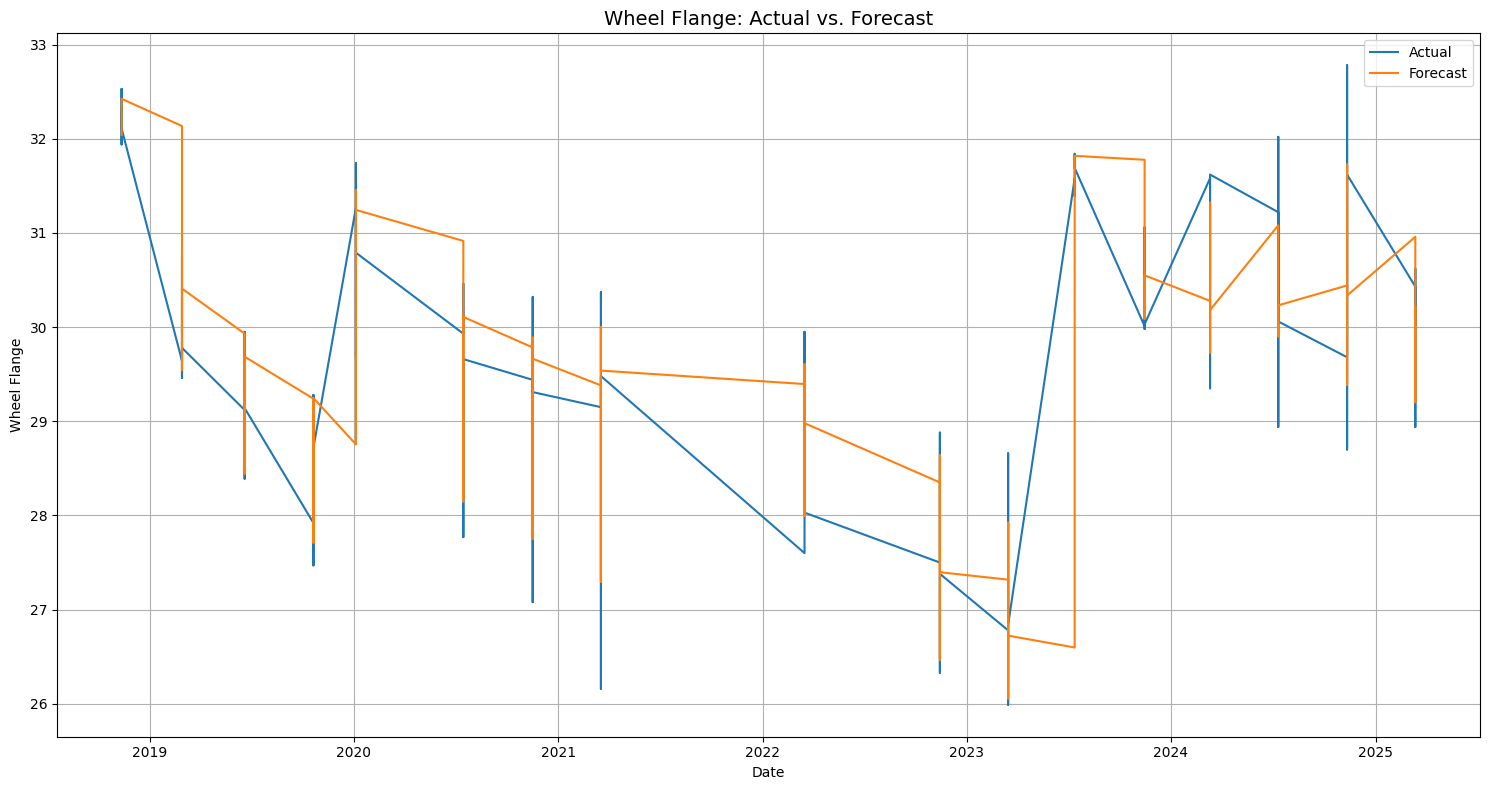

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure testing index is datetime
if not np.issubdtype(testing_wf.index.dtype, np.datetime64):
    testing_wf.index = pd.to_datetime(testing_wf.index)

# Convert predictions into array and ensure shape matches testing set
c = np.array(predictions3)

# Create DataFrame for forecast with the same index as testing
testing_forecasted3 = pd.DataFrame(c, columns=['forecast3'], index=testing_wf.index)

# Combine actual and predicted values
result3 = pd.DataFrame({
    'Actual Wheel Flange': testing_wf['WheelFlange'],
    'Predicted Wheel Flange': testing_forecasted3['forecast3']
})

# Plotting
plt.figure(figsize=(15, 8))
# Use result2 which contains the MTBF actual and predicted values
plt.plot(result3['Actual Wheel Flange'], label='Actual')
plt.plot(result3['Predicted Wheel Flange'], label='Forecast')
plt.title('Wheel Flange: Actual vs. Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Wheel Flange')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Display the top rows of the result DataFrame
print(result3.head(10))

            Actual Wheel Flange  Predicted Wheel Flange
Date                                                   
2018-11-12                32.30               32.041446
2018-11-12                32.18               32.353789
2018-11-12                31.94               32.161813
2018-11-12                32.24               32.088038
2018-11-12                32.18               32.060574
2018-11-12                32.22               32.281685
2018-11-12                32.53               32.150447
2018-11-12                32.11               32.424491
2019-02-28                29.64               32.135529
2019-02-28                30.04               30.888973


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Actual and predicted values
y_true3 = testing_wf['WheelFlange'].values
y_pred3 = testing_forecasted3['forecast3'].values

# Evaluation metrics
r2 = r2_score(y_true3, y_pred3)
mse = mean_squared_error(y_true3, y_pred3)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true3, y_pred3)
mape = np.mean(np.abs((y_true3 - y_pred3) / y_true3)) * 100  # in percentage

# Print results
print(f"R² Score      : {r2:.4f}")
print(f"MSE           : {mse:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"MAE           : {mae:.4f}")
print(f"MAPE (%)      : {mape:.2f}%")

R² Score      : 0.6808
MSE           : 0.5148
RMSE          : 0.7175
MAE           : 0.5013
MAPE (%)      : 1.70%


In [ ]:
import pandas as pd

# Parameters
future_start_date = '2026-01-01'
n_periods = 4
freq = 'Q'
TrainID = ['T01', 'T05', 'T25', 'T45', 'T46', 'T55', 'T57', 'T58']

# Generate future dates
future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)

# Forecast 4 quarters ahead using the model
forecast_values3 = model3.forecast(steps=n_periods)

# Create forecast DataFrame
forecasts3 = pd.DataFrame()

# Assign same forecast to each TrainID
for train_id in TrainID:
    temp_df = pd.DataFrame({
        'TrainID': [train_id] * n_periods,
        'Date': future_dates,
        'Forecast': forecast_values3
    })
    forecasts3 = pd.concat([forecasts3, temp_df], ignore_index=True)

# Display result
print(forecasts3)

   TrainID       Date   Forecast
0      T01 2026-03-31  30.148554
1      T01 2026-06-30  29.993013
2      T01 2026-09-30  29.917003
3      T01 2026-12-31  30.114324
4      T05 2026-03-31  30.148554
5      T05 2026-06-30  29.993013
6      T05 2026-09-30  29.917003
7      T05 2026-12-31  30.114324
8      T25 2026-03-31  30.148554
9      T25 2026-06-30  29.993013
10     T25 2026-09-30  29.917003
11     T25 2026-12-31  30.114324
12     T45 2026-03-31  30.148554
13     T45 2026-06-30  29.993013
14     T45 2026-09-30  29.917003
15     T45 2026-12-31  30.114324
16     T46 2026-03-31  30.148554
17     T46 2026-06-30  29.993013
18     T46 2026-09-30  29.917003
19     T46 2026-12-31  30.114324
20     T55 2026-03-31  30.148554
21     T55 2026-06-30  29.993013
22     T55 2026-09-30  29.917003
23     T55 2026-12-31  30.114324
24     T57 2026-03-31  30.148554
25     T57 2026-06-30  29.993013
26     T57 2026-09-30  29.917003
27     T57 2026-12-31  30.114324
28     T58 2026-03-31  30.148554
29     T58

<ipython-input-35-613988978976>:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=future_start_date, periods=n_periods, freq=freq)
